In [ ]:
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path
from numpy.lib.stride_tricks import sliding_window_view
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_sHcore,
    precision_recall_curve, classification_report
)
from scipy import stats

warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')

PyTorch: 2.12.0+cu132
CUDA disponible: True


In [2]:
BASE_DATA_DIR = '../data'
OUTPUT_DIR = '../data/processed'
MODELS_DIR = '../models'
RESULTS_DIR = '../results'

SEQ_LEN = 4
MAX_SEQ_LEN = 24
PREDICTION_HORIZON_H = 6
MIN_HOURS = SEQ_LEN

BATCH_SIZE = 256
EPOCHS = 150
LR = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.4
PATIENCE = 25
WARMUP_EPOCHS = 5
LAMBDA_SOFA = 0.2

RANDOM_STATE_SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Dispositivo: {DEVICE}')
colors = {'BiLSTM': '#1f77b4', 'BiGRU': '#ff7f0e', 'BiRNN': '#2ca02c'}

Dispositivo: cuda


In [3]:
features_df = pd.read_parquet(f'{OUTPUT_DIR}/features_df.parquet')
cohort_df = pd.read_parquet(f'{OUTPUT_DIR}/cohort_df.parquet')

FEATURE_COLS = [c for c in features_df.columns if c not in ['stay_id', 'hour_bucket', 'Bands']]
N_FEATURES = len(FEATURE_COLS)

cohort_df['intime'] = pd.to_datetime(cohort_df['intime'])
cohort_df['sepsis_onset'] = pd.to_datetime(cohort_df['sepsis_onset'])
cohort_df['onset_h'] = np.where(
    cohort_df['label'] == 1,
    (cohort_df['sepsis_onset'] - cohort_df['intime']).dt.total_seconds() / 3600,
    np.nan
)

ONSET_H_MAP = cohort_df.set_index('stay_id')['onset_h'].to_dict()
LABEL_MAP = cohort_df.set_index('stay_id')['label'].to_dict()

sofa_hourly = pd.read_parquet(f'{OUTPUT_DIR}/sofa_hourly.parquet')
sofa_hourly['hour_bucket'] = sofa_hourly['h_since_intime'].astype(int)
SOFA_LOOKUP = sofa_hourly.set_index(['stay_id', 'hour_bucket'])['sofa'].to_dict()

print(f'Estancias totales: {cohort_df["stay_id"].nunique():,}')
print(f'  Sepsis: {(cohort_df["label"]==1).sum():,} | Control: {(cohort_df["label"]==0).sum():,}')
print(f'Features ({N_FEATURES}): {FEATURE_COLS}')

Estancias totales: 74,754
  Sepsis: 37,377 | Control: 37,377
Features (26): ['Arterial Blood Pressure mean', 'GCS - Motor Response', 'GCS - Verbal Response', 'Heart Rate', 'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure systolic', 'O2 saturation pulseoxymetry', 'PEEP set', 'Respiratory Rate', 'Temperature Celsius', 'Bicarbonate', 'Bilirubin, Total', 'Creatinine', 'Glucose', 'Lactate', 'Platelet Count', 'Urea Nitrogen', 'White Blood Cells', 'pH', 'pO2', 'urine_output_ml', 'vasopressor_active', 'mechanical_ventilation', 'age', 'gender_enc', 'charlson_score']


In [4]:
stays_coverage = features_df.groupby('stay_id')['hour_bucket'].count()
valid_stay_ids = stays_coverage[stays_coverage >= MIN_HOURS].index

stay_labels_v = cohort_df[cohort_df['stay_id'].isin(valid_stay_ids)][
    ['stay_id', 'label', 'subject_id']
].reset_index(drop=True)

all_stays = stay_labels_v['stay_id'].values
all_labels = stay_labels_v['label'].values
all_subjects = stay_labels_v['subject_id'].values

first_shuffle_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE_SEED)
tv_idx, test_idx = next(first_shuffle_split.split(all_stays, all_labels, groups=all_subjects))

second_shuffle_split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE_SEED)
tr_idx, val_idx = next(second_shuffle_split.split(all_stays[tv_idx], all_labels[tv_idx], groups=all_subjects[tv_idx]))

train_stays = all_stays[tv_idx][tr_idx]
val_stays   = all_stays[tv_idx][val_idx]
test_stays  = all_stays[test_idx]

stay_to_subject = cohort_df.set_index('stay_id')['subject_id']
train_sub = set(stay_to_subject[stay_to_subject.index.isin(train_stays)])
val_sub   = set(stay_to_subject[stay_to_subject.index.isin(val_stays)])
test_sub  = set(stay_to_subject[stay_to_subject.index.isin(test_stays)])

print(f'Train: {len(train_stays):,} estancias | {len(train_sub):,} pacientes')
print(f'Val:   {len(val_stays):,} estancias | {len(val_sub):,} pacientes')
print(f'Test:  {len(test_stays):,} estancias | {len(test_sub):,} pacientes')

Train: 44,794 estancias | 32,220 pacientes
Val:   14,889 estancias | 10,740 pacientes
Test:  14,871 estancias | 10,740 pacientes


In [5]:
def build_sequences(features_df, stay_ids, feature_cols, onset_h_map, label_map,
                     sofa_lookup=None, max_seq_len=MAX_SEQ_LEN, seq_len=SEQ_LEN,
                     horizon_h=PREDICTION_HORIZON_H):
    F = len(feature_cols)
    features_grouped_by_stay = dict(tuple(
        features_df[features_df['stay_id'].isin(stay_ids)].groupby('stay_id')
    ))

    X_list, y_list, sid_list, lead_list, sofa_list, len_list = [], [], [], [], [], []

    for stay_id in stay_ids:
        if stay_id not in features_grouped_by_stay:
            continue

        df_s = features_grouped_by_stay[stay_id].sort_values('hour_bucket')
        is_sepsis = label_map.get(stay_id, 0)
        onset_hour = onset_h_map.get(stay_id)

        MIN_ONSET_H = 6
        if is_sepsis and onset_hour is not None and not pd.isna(onset_hour) and onset_hour < MIN_ONSET_H:
            continue

        CONTROL_MAX_LOS_H = 168
        if is_sepsis and onset_hour is not None and not pd.isna(onset_hour):
            max_hour = int(onset_hour) - 1
        else:
            max_hour = min(int(df_s['hour_bucket'].max()), CONTROL_MAX_LOS_H - 1)

        df_s = df_s[df_s['hour_bucket'].between(0, max_hour)]
        if df_s['hour_bucket'].nunique() < seq_len:
            continue

        grid = np.full((max_hour + 1, F), np.nan, dtype=np.float32)
        hb_vals = df_s['hour_bucket'].astype(int).values
        feat_vals = df_s[feature_cols].values.astype(np.float32)
        valid_mask = (hb_vals >= 0) & (hb_vals <= max_hour)
        grid[hb_vals[valid_mask]] = feat_vals[valid_mask]

        num_hours = max_hour + 1
        num_windows = num_hours

        padded = np.full((max_seq_len - 1 + num_hours, F), np.nan, dtype=np.float32)
        padded[max_seq_len - 1:] = grid

        windows = sliding_window_view(padded, (max_seq_len, F)).reshape(-1, max_seq_len, F)
        lengths_arr = np.minimum(np.arange(1, num_windows + 1, dtype=np.int64), max_seq_len)
        end_hour = np.arange(num_windows, dtype=np.float32)

        if is_sepsis and onset_hour is not None and not pd.isna(onset_hour):
            hour_to_onset = float(onset_hour) - end_hour
            labels = ((hour_to_onset > 0) & (hour_to_onset <= horizon_h)).astype(np.float32)
            leads = hour_to_onset
        else:
            labels = np.zeros(num_windows, dtype=np.float32)
            leads = np.full(num_windows, np.nan, dtype=np.float32)

        MAX_WINDOWS_PER_CONTROL = 30
        if not is_sepsis and num_windows > MAX_WINDOWS_PER_CONTROL:
            keep_idx = np.linspace(0, num_windows - 1, MAX_WINDOWS_PER_CONTROL).astype(int)
            windows = windows[keep_idx]
            labels = labels[keep_idx]
            leads = leads[keep_idx]
            lengths_arr = lengths_arr[keep_idx]
            end_hour = end_hour[keep_idx]

        if sofa_lookup is not None:
            sofa_window = np.array(
                [sofa_lookup.get((stay_id, int(h)), np.nan) for h in end_hour],
                dtype=np.float32
            )
        else:
            sofa_window = np.full(len(windows), np.nan, dtype=np.float32)

        X_list.append(windows)
        y_list.append(labels)
        sid_list.extend([stay_id] * len(windows))
        lead_list.append(leads)
        sofa_list.append(sofa_window)
        len_list.append(lengths_arr)

    if not X_list:
        empty = np.empty((0, max_seq_len, F), dtype=np.float32)
        return empty, np.array([]), np.array([]), np.array([]), np.array([]), np.array([], dtype=np.int64)

    return (
        np.concatenate(X_list, axis=0),
        np.concatenate(y_list, axis=0),
        np.array(sid_list),
        np.concatenate(lead_list, axis=0),
        np.concatenate(sofa_list, axis=0),
        np.concatenate(len_list, axis=0),
    )

In [6]:
X_train, y_train, sids_train, leads_train, sofa_train, lens_train = build_sequences(
    features_df, train_stays, FEATURE_COLS, ONSET_H_MAP, LABEL_MAP, SOFA_LOOKUP)
X_val,   y_val,   sids_val,   leads_val,   sofa_val,   lens_val   = build_sequences(
    features_df, val_stays,   FEATURE_COLS, ONSET_H_MAP, LABEL_MAP, SOFA_LOOKUP)
X_test,  y_test,  sids_test,  leads_test,  sofa_test,  lens_test  = build_sequences(
    features_df, test_stays,  FEATURE_COLS, ONSET_H_MAP, LABEL_MAP, SOFA_LOOKUP)

print(f'X_train: {X_train.shape} | positivos: {y_train.mean():.2%} | len media: {lens_train.mean():.1f}h')
print(f'X_val:   {X_val.shape}   | positivos: {y_val.mean():.2%}   | len media: {lens_val.mean():.1f}h')
print(f'X_test:  {X_test.shape}  | positivos: {y_test.mean():.2%}  | len media: {lens_test.mean():.1f}h')

X_train: (759894, 24, 26) | positivos: 5.05% | len media: 16.5h
X_val:   (252310, 24, 26)   | positivos: 5.09%   | len media: 16.5h
X_test:  (252116, 24, 26)  | positivos: 4.90%  | len media: 16.6h


In [7]:
NEG_POS_RATIO = 10
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
n_neg_keep = min(len(neg_idx), len(pos_idx) * NEG_POS_RATIO)
_rng = np.random.default_rng(RANDOM_STATE_SEED)
neg_keep = _rng.choice(neg_idx, size=n_neg_keep, replace=False)
keep = np.sort(np.concatenate([pos_idx, neg_keep]))
X_train     = X_train[keep]
y_train     = y_train[keep]
sids_train  = sids_train[keep]
leads_train = leads_train[keep]
sofa_train  = sofa_train[keep]
lens_train  = lens_train[keep]
print(f'Tras subsampling — X_train: {X_train.shape} | positivos: {y_train.mean():.2%}')

Tras subsampling — X_train: (422070, 24, 26) | positivos: 9.09%


In [8]:
def apply_forward_fill_vectorized(X, max_gap=24):
    n, T, F = X.shape
    X_ff = X.copy()
    arange_T = np.arange(T)
    for j in range(F):
        arr  = X_ff[:, :, j]
        mask = ~np.isnan(arr)
        idx  = np.where(mask, arange_T, 0)
        np.maximum.accumulate(idx, axis=1, out=idx)
        gap  = arange_T[None, :] - idx
        filled = arr[np.arange(n)[:, None], idx]
        too_old = gap > max_gap
        filled = np.where(too_old, np.nan, filled)
        X_ff[:, :, j] = filled
    return X_ff

M_train = (~np.isnan(X_train)).astype(np.float32)
M_val   = (~np.isnan(X_val)).astype(np.float32)
M_test  = (~np.isnan(X_test)).astype(np.float32)

X_train_ff = apply_forward_fill_vectorized(X_train)
X_val_ff   = apply_forward_fill_vectorized(X_val)
X_test_ff  = apply_forward_fill_vectorized(X_test)

print(f'NaN antes ffill: {np.isnan(X_train).mean():.1%} | después: {np.isnan(X_train_ff).mean():.1%}')

NaN antes ffill: 70.3% | después: 51.7%


In [9]:
def compute_deltas(X_ff, M_original=None):
    deltas = np.zeros_like(X_ff)
    diff = X_ff[:, 1:, :] - X_ff[:, :-1, :]
    deltas[:, 1:, :] = np.where(np.isnan(diff), 0.0, diff)
    if M_original is not None:
        both_measured = M_original[:, 1:, :] * M_original[:, :-1, :]
        deltas[:, 1:, :] *= both_measured
    return deltas.astype(np.float32)

deltas_train = compute_deltas(X_train_ff, M_train)
deltas_val   = compute_deltas(X_val_ff,   M_val)
deltas_test  = compute_deltas(X_test_ff,  M_test)
print(f'Deltas train shape: {deltas_train.shape} | no nulos: {(deltas_train!=0).mean():.2%}')

Deltas train shape: (422070, 24, 26) | no nulos: 9.76%


In [10]:
def apply_missingness_mask(X, train_medians=None, external_mask=None, external_deltas=None):
    _, _, F = X.shape
    M = external_mask if external_mask is not None else (~np.isnan(X)).astype(np.float32)
    X_imp = X.copy()
    if train_medians is None:
        flat = X_imp.reshape(-1, F)
        train_medians = np.nanmedian(flat, axis=0)
        train_medians = np.where(np.isnan(train_medians), 0.0, train_medians)
    for j in range(F):
        mask_nan = np.isnan(X_imp[:, :, j])
        X_imp[:, :, j][mask_nan] = train_medians[j]
    parts = [X_imp]
    if external_deltas is not None:
        parts.append(external_deltas)
    parts.append(M)
    X_out = np.concatenate(parts, axis=2).astype(np.float32)
    return X_out, train_medians

X_train_masked, train_medians = apply_missingness_mask(X_train_ff, external_mask=M_train, external_deltas=deltas_train)
X_val_masked, _   = apply_missingness_mask(X_val_ff,   train_medians, external_mask=M_val,   external_deltas=deltas_val)
X_test_masked, _  = apply_missingness_mask(X_test_ff,  train_medians, external_mask=M_test,  external_deltas=deltas_test)
print(f'Shape final: {X_train_masked.shape} → input_size: {X_train_masked.shape[2]}')

Shape final: (422070, 24, 78) → input_size: 78


In [11]:
scaler = StandardScaler()

def scale_masked(X, scaler, F, fit=False):
    n, T, F_total = X.shape
    has_deltas = (F_total == 3 * F)
    X_vals = X[:, :, :F].reshape(-1, F)
    if fit:
        X_vals_scaled = scaler.fit_transform(X_vals)
    else:
        X_vals_scaled = scaler.transform(X_vals)
    X_vals_scaled = X_vals_scaled.reshape(n, T, F).astype(np.float32)
    if has_deltas:
        delta_std = np.where(scaler.scale_ > 0, scaler.scale_, 1.0)
        X_deltas = X[:, :, F:2*F].reshape(-1, F)
        X_deltas_scaled = (X_deltas / delta_std).reshape(n, T, F).astype(np.float32)
        X_mask = X[:, :, 2*F:]
        return np.concatenate([X_vals_scaled, X_deltas_scaled, X_mask], axis=2).astype(np.float32)
    else:
        X_mask = X[:, :, F:]
        return np.concatenate([X_vals_scaled, X_mask], axis=2).astype(np.float32)

X_train_norm = scale_masked(X_train_masked, scaler, N_FEATURES, fit=True)
X_val_norm   = scale_masked(X_val_masked,   scaler, N_FEATURES, fit=False)
X_test_norm  = scale_masked(X_test_masked,  scaler, N_FEATURES, fit=False)

N_INPUT = X_train_norm.shape[2]
print(f'Input al modelo: {N_INPUT} (shape {X_train_norm.shape})')

Input al modelo: 78 (shape (422070, 24, 78))


In [12]:
class SepsisDataset(Dataset):
    def __init__(self, X, y, lengths, sofa):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
        self.lengths = torch.from_numpy(lengths).long()
        self.sofa = torch.from_numpy(sofa).float()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx], self.sofa[idx]

train_ds = SepsisDataset(X_train_norm, y_train, lens_train, sofa_train)
val_ds   = SepsisDataset(X_val_norm,   y_val,   lens_val,   sofa_val)
test_ds  = SepsisDataset(X_test_norm,  y_test,  lens_test,  sofa_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} x {BATCH_SIZE}')

Train batches: 1648 x 256


In [13]:
class Bi_LSTM_Sepsis(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0, bidirectional=True)
        lstm_out_size = hidden_size * 2
        self.attn = nn.Linear(lstm_out_size, 1)
        self.bn1 = nn.BatchNorm1d(lstm_out_size)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(lstm_out_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        self.fc_sofa = nn.Linear(64, 1)

    def forward(self, x, lengths=None):
        out, _ = self.lstm(x)
        attn_logits = self.attn(out).squeeze(-1)
        if lengths is not None:
            T = out.size(1)
            positions = torch.arange(T, device=x.device).unsqueeze(0)
            pad_start = T - lengths.unsqueeze(1)
            real_mask = positions >= pad_start
            attn_logits = attn_logits.masked_fill(~real_mask, float('-inf'))
        attn_weights = torch.softmax(attn_logits, dim=1).unsqueeze(-1)
        context = (attn_weights * out).sum(dim=1)
        context = self.bn1(context)
        context = self.dropout(context)
        shared = self.relu(self.fc1(context))
        return self.fc2(shared).squeeze(-1), self.fc_sofa(shared).squeeze(-1)


class Bi_GRU_Sepsis(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0, bidirectional=True)
        d = hidden_size * 2
        self.attn = nn.Linear(d, 1)
        self.bn1 = nn.BatchNorm1d(d)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(d, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        self.fc_sofa = nn.Linear(64, 1)

    def forward(self, x, lengths=None):
        out, _ = self.gru(x)
        attn_logits = self.attn(out).squeeze(-1)
        if lengths is not None:
            T = out.size(1)
            positions = torch.arange(T, device=x.device).unsqueeze(0)
            real_mask = positions >= (T - lengths.unsqueeze(1))
            attn_logits = attn_logits.masked_fill(~real_mask, float('-inf'))
        attn_w = torch.softmax(attn_logits, dim=1).unsqueeze(-1)
        context = self.dropout(self.bn1((attn_w * out).sum(dim=1)))
        shared = self.relu(self.fc1(context))
        return self.fc2(shared).squeeze(-1), self.fc_sofa(shared).squeeze(-1)


class Bi_RNN_Sepsis(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
                          bidirectional=True, nonlinearity='tanh')
        d = hidden_size * 2
        self.attn = nn.Linear(d, 1)
        self.bn1 = nn.BatchNorm1d(d)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(d, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        self.fc_sofa = nn.Linear(64, 1)

    def forward(self, x, lengths=None):
        out, _ = self.rnn(x)
        attn_logits = self.attn(out).squeeze(-1)
        if lengths is not None:
            T = out.size(1)
            positions = torch.arange(T, device=x.device).unsqueeze(0)
            real_mask = positions >= (T - lengths.unsqueeze(1))
            attn_logits = attn_logits.masked_fill(~real_mask, float('-inf'))
        attn_w = torch.softmax(attn_logits, dim=1).unsqueeze(-1)
        context = self.dropout(self.bn1((attn_w * out).sum(dim=1)))
        shared = self.relu(self.fc1(context))
        return self.fc2(shared).squeeze(-1), self.fc_sofa(shared).squeeze(-1)

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = alpha_t * (1 - p_t) ** self.gamma * bce
        return focal.mean()


def sofa_auxiliary_loss(sofa_pred, sofa_true):
    mask = ~torch.isnan(sofa_true)
    if not mask.any():
        return torch.tensor(0.0, device=sofa_pred.device)
    return nn.functional.mse_loss(sofa_pred[mask], sofa_true[mask] / 24.0)


def train_model(model, model_name):
    focal_loss = FocalLoss(alpha=0.25, gamma=2.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=7, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'val_auroc': []}
    best_val_auroc = 0.0
    patience_counter = 0
    best_path = f'{MODELS_DIR}/{model_name}.pt'

    for epoch in range(1, EPOCHS + 1):
        if epoch <= WARMUP_EPOCHS:
            warmup_lr = LR * epoch / WARMUP_EPOCHS
            for g in optimizer.param_groups:
                g['lr'] = warmup_lr

        # Entrenamiento
        model.train()
        train_loss = 0.0
        train_samples = 0
        for X_b, y_b, len_b, sofa_b in train_loader:
            X_b, y_b, len_b, sofa_b = X_b.to(DEVICE), y_b.to(DEVICE), len_b.to(DEVICE), sofa_b.to(DEVICE)
            optimizer.zero_grad()
            sepsis_logit, sofa_pred = model(X_b, len_b)
            loss = focal_loss(sepsis_logit, y_b) + LAMBDA_SOFA * sofa_auxiliary_loss(sofa_pred, sofa_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(y_b)
            train_samples += len(y_b)
        train_loss /= train_samples

        # Validación
        model.eval()
        val_loss = 0.0
        val_probs, val_true = [], []
        with torch.no_grad():
            for X_b, y_b, len_b, sofa_b in val_loader:
                X_b, y_b, len_b, sofa_b = X_b.to(DEVICE), y_b.to(DEVICE), len_b.to(DEVICE), sofa_b.to(DEVICE)
                sepsis_logit, sofa_pred = model(X_b, len_b)
                loss = focal_loss(sepsis_logit, y_b) + LAMBDA_SOFA * sofa_auxiliary_loss(sofa_pred, sofa_b)
                val_loss += loss.item() * len(y_b)
                val_probs.extend(torch.sigmoid(sepsis_logit).cpu().numpy())
                val_true.extend(y_b.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_auroc = roc_auc_score(val_true, val_probs) if len(set(val_true)) > 1 else 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auroc'].append(val_auroc)

        old_lr = optimizer.param_groups[0]['lr']
        if epoch > WARMUP_EPOCHS:
            scheduler.step(val_auroc)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < old_lr:
            print(f'--- LR reducido a: {new_lr:.2e} ---')

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_counter += 1

        print(f'Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
              f'Val AUROC: {val_auroc:.4f} | LR: {new_lr:.2e} | P: {patience_counter}')

        if patience_counter >= PATIENCE:
            print(f'Early stopping en epoch {epoch}.')
            break

    print(f'\nMejor val_auroc: {best_val_auroc:.4f}')
    return {'history': history, 'path': best_path, 'model': model}

print('Funciones de entrenamiento listas.')

Funciones de entrenamiento listas.


## Carga del BiLSTM entrenado

Si ya existe el checkpoint de entrenamiento previo, se carga directamente. Si no, se entrena desde cero.

In [15]:
lstm_model = Bi_LSTM_Sepsis(input_size=N_INPUT).to(DEVICE)
lstm_path = f'{MODELS_DIR}/best_lstm_multitask.pt'

if Path(lstm_path).exists():
    lstm_model.load_state_dict(torch.load(lstm_path, map_location=DEVICE, weights_only=True))
    lstm_model.eval()
    print(f'BiLSTM cargado desde {lstm_path}')
    # Histórico vacío porque no se entrenó aquí
    history_lstm = {'train_loss': [], 'val_loss': [], 'val_auroc': []}
else:
    print('No se encontró checkpoint de BiLSTM. Entrenando desde cero...')
    result_lstm = train_model(lstm_model, 'best_lstm_multitask')
    history_lstm = result_lstm['history']
    lstm_path = result_lstm['path']

BiLSTM cargado desde ../models/best_lstm_multitask.pt


## Entrenamiento BiGRU y BiRNN

Se entrenan desde cero con los mismos hiperparámetros y semilla, variando únicamente la celda recurrente.

In [16]:
gru_model = Bi_GRU_Sepsis(input_size=N_INPUT).to(DEVICE)
rnn_model = Bi_RNN_Sepsis(input_size=N_INPUT).to(DEVICE)

for name, m in [('GRU', gru_model), ('RNN', rnn_model)]:
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name}: {n:,} parámetros entrenables')

print('\n--- Entrenando BiGRU ---')
result_gru = train_model(gru_model, 'best_gru_multitask')
path_gru = result_gru['path']
history_gru = result_gru['history']

print('\n--- Entrenando BiRNN ---')
result_rnn = train_model(rnn_model, 'best_rnn_multitask')
path_rnn = result_rnn['path']
history_rnn = result_rnn['history']

GRU: 64,067 parámetros entrenables
RNN: 27,203 parámetros entrenables

--- Entrenando BiGRU ---
Epoch   1/150 | Train Loss: 0.0315 | Val Loss: 0.0190 | Val AUROC: 0.7767 | LR: 2.00e-04 | P: 0
Epoch   2/150 | Train Loss: 0.0261 | Val Loss: 0.0189 | Val AUROC: 0.7919 | LR: 4.00e-04 | P: 0
Epoch   3/150 | Train Loss: 0.0255 | Val Loss: 0.0185 | Val AUROC: 0.7956 | LR: 6.00e-04 | P: 0
Epoch   4/150 | Train Loss: 0.0254 | Val Loss: 0.0177 | Val AUROC: 0.7945 | LR: 8.00e-04 | P: 1
Epoch   5/150 | Train Loss: 0.0254 | Val Loss: 0.0182 | Val AUROC: 0.7940 | LR: 1.00e-03 | P: 2
Epoch   6/150 | Train Loss: 0.0253 | Val Loss: 0.0179 | Val AUROC: 0.7965 | LR: 1.00e-03 | P: 0
Epoch   7/150 | Train Loss: 0.0253 | Val Loss: 0.0176 | Val AUROC: 0.7954 | LR: 1.00e-03 | P: 1
Epoch   8/150 | Train Loss: 0.0252 | Val Loss: 0.0177 | Val AUROC: 0.7977 | LR: 1.00e-03 | P: 0
Epoch   9/150 | Train Loss: 0.0252 | Val Loss: 0.0182 | Val AUROC: 0.7991 | LR: 1.00e-03 | P: 0
Epoch  10/150 | Train Loss: 0.0251 | Val

## A/B Test — Evaluación comparativa

- **AUROC** y **AUPRC** con IC bootstrap (1000 iteraciones, α=0.05)
- **Test de DeLong** para comparar AUROCs por pares
- Métricas clínicas: precisión @ recall fijo, tiempo de alerta anticipada

In [17]:
def get_test_probs(m, path):
    m.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=True))
    m.eval()
    probs, labels = [], []
    with torch.no_grad():
        for X_b, y_b, len_b, _ in test_loader:
            logit, _ = m(X_b.to(DEVICE), len_b.to(DEVICE))
            probs.extend(torch.sigmoid(logit).cpu().numpy())
            labels.extend(y_b.numpy())
    return np.array(probs), np.array(labels)


def bootstrap_metric(y_true, y_score, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, ys = y_true[idx], y_score[idx]
        if len(np.unique(yt)) > 1:
            scores.append(metric_fn(yt, ys))
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def delong_test(y_true, pred1, pred2):
    """DeLong U-statistics para diferencia de AUROCs. Retorna (auc1, auc2, z, p)."""
    pos = np.where(y_true == 1)[0]
    neg = np.where(y_true == 0)[0]
    m, n = len(pos), len(neg)
    if m < 2 or n < 2:
        return 0.0, 0.0, 0.0, 1.0

    def components(scores):
        sp, sn = scores[pos], scores[neg]
        V10 = np.array([(sp[i] > sn).mean() + 0.5 * (sp[i] == sn).mean() for i in range(m)])
        V01 = np.array([(sn[j] < sp).mean() + 0.5 * (sn[j] == sp).mean() for j in range(n)])
        return V10, V01

    V10_1, V01_1 = components(pred1)
    V10_2, V01_2 = components(pred2)

    # Covarianza con rowvar=False para tratar cada variable como columna
    S_V10 = np.cov(np.vstack([V10_1, V10_2]), rowvar=False) / m if m > 1 else np.zeros((2,2))
    S_V01 = np.cov(np.vstack([V01_1, V01_2]), rowvar=False) / n if n > 1 else np.zeros((2,2))
    S = S_V10 + S_V01

    L = np.array([1, -1])
    auc_diff = V10_1.mean() - V10_2.mean()
    var_diff = max(L @ S @ L, 1e-12)
    z = auc_diff / np.sqrt(var_diff)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return V10_1.mean(), V10_2.mean(), z, p


probs_lstm, y_true = get_test_probs(lstm_model, lstm_path)
probs_gru,  _      = get_test_probs(gru_model,  path_gru)
probs_rnn,  _      = get_test_probs(rnn_model,  path_rnn)
print('Predicciones obtenidas para los 3 modelos.')

Predicciones obtenidas para los 3 modelos.


In [18]:
results = {}
for name, probs in [('BiLSTM', probs_lstm), ('BiGRU', probs_gru), ('BiRNN', probs_rnn)]:
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    _, lo_roc, hi_roc = bootstrap_metric(y_true, probs, roc_auc_score)
    _, lo_prc, hi_prc = bootstrap_metric(y_true, probs, average_precision_score)
    results[name] = {'probs': probs, 'auroc': auroc, 'auprc': auprc,
                     'auroc_ci': (lo_roc, hi_roc), 'auprc_ci': (lo_prc, hi_prc)}
    print(f'{name:8s}  AUROC={auroc:.4f} [{lo_roc:.4f}–{hi_roc:.4f}]  '
          f'AUPRC={auprc:.4f} [{lo_prc:.4f}–{hi_prc:.4f}]')

BiLSTM    AUROC=0.8107 [0.8068–0.8145]  AUPRC=0.2065 [0.1999–0.2137]
BiGRU     AUROC=0.8108 [0.8070–0.8150]  AUPRC=0.2112 [0.2046–0.2186]
BiRNN     AUROC=0.8135 [0.8098–0.8173]  AUPRC=0.2135 [0.2068–0.2208]


In [20]:
leads_arr = np.array(leads_test)

print('Precisión @ recall objetivo:')
for name, d in results.items():
    fpr, tpr, thr = roc_curve(y_true, d['probs'])
    row = f'{name:8s}'
    for tr in [0.30, 0.50, 0.70]:
        idx = np.where(tpr >= tr)[0]
        if len(idx):
            sel  = d['probs'] >= thr[idx[0]]
            prec = (sel & (y_true == 1)).sum() / max(sel.sum(), 1)
            row += f'  Rec{tr:.0%}→prec={prec:.3f}'
    print(row)

print('\nPrecision @ top-k:')
for name, d in results.items():
    row = f'{name:8s}'
    for pct in [0.01, 0.05, 0.10]:
        k = max(int(len(d['probs']) * pct), 1)
        row += f'  Top-{pct:.0%}={y_true[np.argsort(-d["probs"])[:k]].mean():.3f}'
    print(row)

print('\nLead time (umbral Youden):')
print(f'{"Modelo":8s}  Umbral  Media   Mediana  TP       FN')
for name, d in results.items():
    fpr, tpr, thr = roc_curve(y_true, d['probs'])
    bt   = thr[np.argmax(tpr - fpr)]
    pred = d['probs'] >= bt
    tp   = (y_true == 1) & pred & ~np.isnan(leads_arr)
    fn   = (y_true == 1) & ~pred & ~np.isnan(leads_arr)
    lm   = leads_arr[tp].mean()   if tp.any() else float('nan')
    lmed = np.median(leads_arr[tp]) if tp.any() else float('nan')
    print(f'{name:8s}  {bt:.3f}   {lm:>5.1f}h  {lmed:>6.1f}h  {tp.sum():>7,}  {fn.sum():>7,}')

Precisión @ recall objetivo:
BiLSTM    Rec30%→prec=0.249  Rec50%→prec=0.190  Rec70%→prec=0.132
BiGRU     Rec30%→prec=0.254  Rec50%→prec=0.189  Rec70%→prec=0.135
BiRNN     Rec30%→prec=0.258  Rec50%→prec=0.192  Rec70%→prec=0.136

Precision @ top-k:
BiLSTM    Top-1%=0.370  Top-5%=0.263  Top-10%=0.210
BiGRU     Top-1%=0.395  Top-5%=0.265  Top-10%=0.210
BiRNN     Top-1%=0.392  Top-5%=0.271  Top-10%=0.211

Lead time (umbral Youden):
Modelo    Umbral  Media   Mediana  TP       FN
BiLSTM    0.220     3.4h     3.0h    9,401    2,947
BiGRU     0.223     3.4h     3.0h    9,278    3,070
BiRNN     0.217     3.4h     3.0h    9,342    3,006


## Visualizaciones

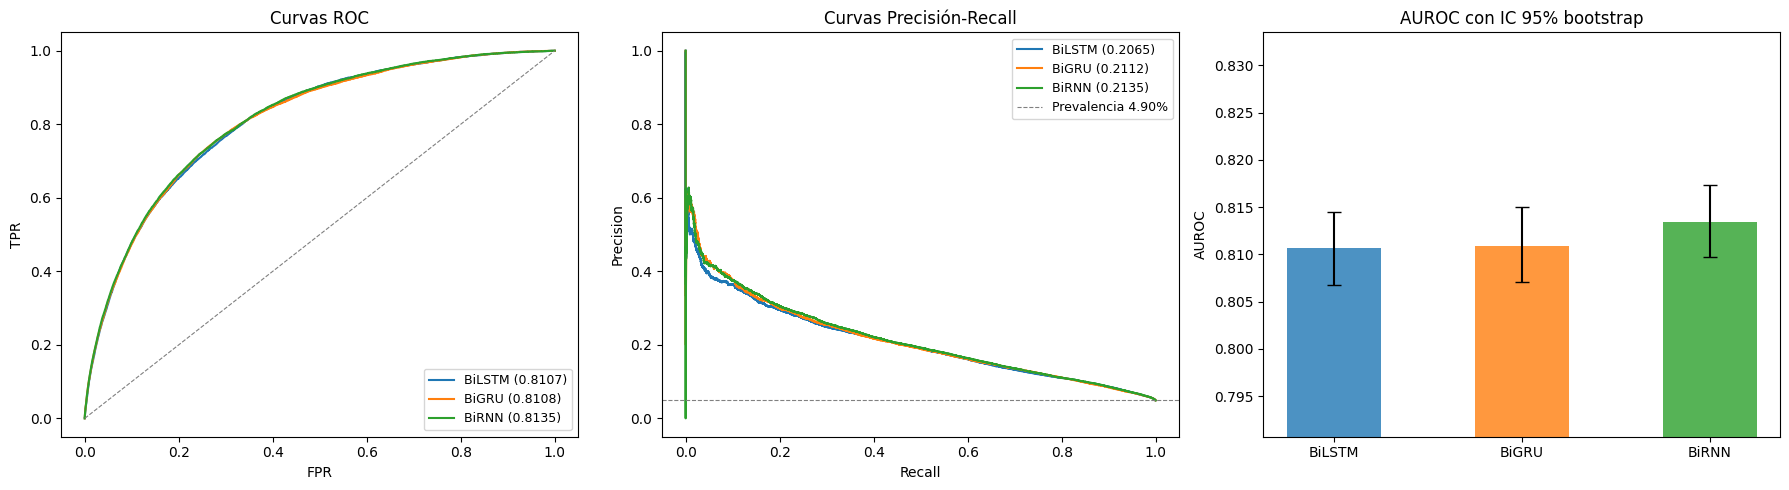

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
ax = axes[0]
for name, d in results.items():
    fpr, tpr, _ = roc_curve(y_true, d['probs'])
    ax.plot(fpr, tpr, label=f"{name} ({d['auroc']:.4f})", color=colors[name])
ax.plot([0,1],[0,1],'--', color='gray', lw=0.8)
ax.set(xlabel='FPR', ylabel='TPR', title='Curvas ROC')
ax.legend(loc='lower right', fontsize=9)

# PR
ax = axes[1]
for name, d in results.items():
    prec, rec, _ = precision_recall_curve(y_true, d['probs'])
    ax.plot(rec, prec, label=f"{name} ({d['auprc']:.4f})", color=colors[name])
ax.axhline(y_true.mean(), color='gray', linestyle='--', lw=0.8,
           label=f'Prevalencia {y_true.mean():.2%}')
ax.set(xlabel='Recall', ylabel='Precision', title='Curvas Precisión-Recall')
ax.legend(loc='upper right', fontsize=9)

# AUROC barplot con IC
ax = axes[2]
names  = list(results.keys())
aurocs = [results[n]['auroc'] for n in names]
errs   = np.array([(results[n]['auroc'] - results[n]['auroc_ci'][0],
                    results[n]['auroc_ci'][1] - results[n]['auroc']) for n in names]).T
ax.bar(range(len(names)), aurocs, color=[colors[n] for n in names], alpha=0.8, width=0.5)
ax.errorbar(range(len(names)), aurocs, yerr=errs, fmt='none', color='black', capsize=5)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names)
ax.set_ylim(min(aurocs) - 0.02, max(aurocs) + 0.02)
ax.set(ylabel='AUROC', title='AUROC con IC 95% bootstrap')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ab_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

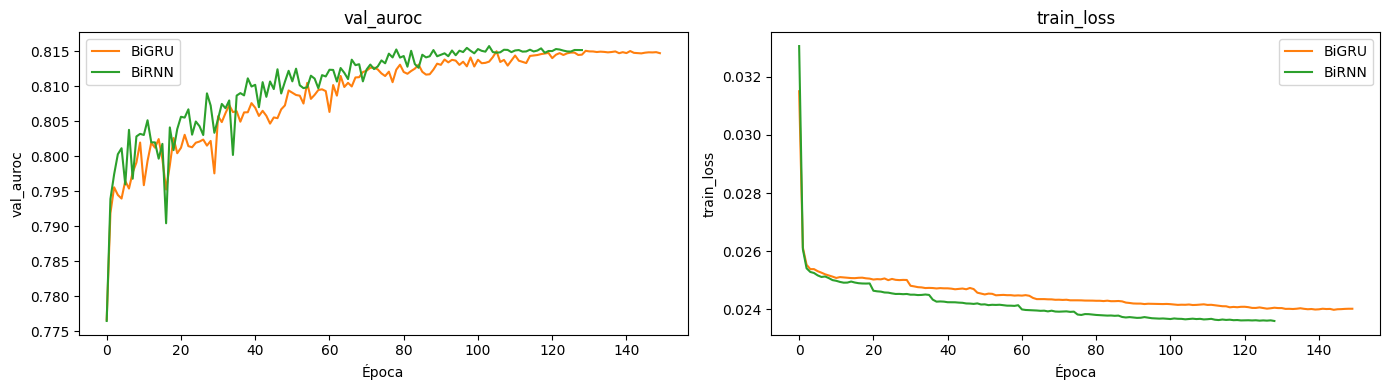

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ['val_auroc', 'train_loss']):
    for name, h in [('BiGRU', history_gru), ('BiRNN', history_rnn)]:
        ax.plot(h[metric], label=name, color=colors[name])
    ax.set(xlabel='Época', ylabel=metric, title=metric)
    ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ab_test_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Resumen final

In [23]:
model_map = {'BiLSTM': lstm_model, 'BiGRU': gru_model, 'BiRNN': rnn_model}
rows = []
for name, d in results.items():
    fpr, tpr, thr = roc_curve(y_true, d['probs'])
    bt     = thr[np.argmax(tpr - fpr)]
    pred   = d['probs'] >= bt
    tp     = (y_true == 1) & pred & ~np.isnan(leads_arr)
    pr, rc, _ = precision_recall_curve(y_true, d['probs'])
    idx    = np.where(pr >= 0.20)[0]
    n_p    = sum(p.numel() for p in model_map[name].parameters() if p.requires_grad)
    rows.append({
        'Modelo':     name,
        'AUROC':      f"{d['auroc']:.4f} [{d['auroc_ci'][0]:.4f}–{d['auroc_ci'][1]:.4f}]",
        'AUPRC':      f"{d['auprc']:.4f} [{d['auprc_ci'][0]:.4f}–{d['auprc_ci'][1]:.4f}]",
        'Rec@Prec≥20%': f'{rc[idx[0]]:.3f}' if len(idx) else 'N/A',
        'Lead(h)':    f'{leads_arr[tp].mean():.1f}' if tp.any() else 'N/A',
        'Params':     f'{n_p:,}',
    })

summary = pd.DataFrame(rows).set_index('Modelo')
print(summary.to_string())
summary.to_csv(f'{RESULTS_DIR}/ab_test_summary.csv')
print(f'\nGuardado en {RESULTS_DIR}/ab_test_summary.csv')

                         AUROC                   AUPRC Rec@Prec≥20% Lead(h)  Params
Modelo                                                                             
BiLSTM  0.8107 [0.8068–0.8145]  0.2065 [0.1999–0.2137]        0.466     3.4  82,499
BiGRU   0.8108 [0.8070–0.8150]  0.2112 [0.2046–0.2186]        0.461     3.4  64,067
BiRNN   0.8135 [0.8098–0.8173]  0.2135 [0.2068–0.2208]        0.472     3.4  27,203

Guardado en ../results/ab_test_summary.csv
